# Session 1 - Code Along: Training a PINN in PyTorch

This is a code-along - please follow along with the lecture!

In this demo we will code a PINN from scratch in `PyTorch` and use it to solve simulation and inversion problems related to the damped harmonic oscillator.

In [17]:
import time

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## Problem overview

We are going to use a PINN to solve problems related to the **damped harmonic oscillator**:

<img src="https://raw.githubusercontent.com/benmoseley/AISE-2024/main/5_introduction_to_PINNs/oscillator.gif" width="500">

We are interested in modelling the displacement of the mass on a spring (green box) over time.

This is a canonical physics problem, where the displacement, $u(t)$, of the oscillator as a function of time can be described by the following differential equation:

$$
m \dfrac{d^2 u}{d t^2} + \mu \dfrac{d u}{d t} + ku = 0~,
$$

where $m$ is the mass of the oscillator, $\mu$ is the coefficient of friction and $k$ is the spring constant.

We will focus on solving the problem in the **under-damped state**, i.e. where the oscillation is slowly damped by friction (as displayed in the animation above).

Mathematically, this occurs when:

$$
\delta < \omega_0~,~~~~~\mathrm{where}~~\delta = \dfrac{\mu}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$

Furthermore, we consider the following initial conditions of the system:

$$
u(t=0) = 1~~,~~\dfrac{d u}{d t}(t=0) = 0~.
$$

For this particular case, the exact solution is known and given by:

$$
u(t) = e^{-\delta t}(2 A \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$



For a more detailed mathematical description of the harmonic oscillator, check out this blog post: https://beltoforion.de/en/harmonic_oscillator/.

## Workflow overview

There are **two scientific tasks** related to the harmonic oscillator we will use a PINN for:

>First, we will **simulate** the system using a PINN, given its initial conditions.

>Second, we will **invert** for underlying parameters of the system using a PINN, given some noisy observations of the oscillator's displacement.

## Initial setup

First, we define a few helper functions.

In [18]:
def exact_solution(d, w0, t):
    "Defines the analytical solution to the under-damped harmonic oscillator problem above."
    assert d < w0
    w = np.sqrt(w0**2-d**2)
    phi = np.arctan(-d/w)
    A = 1/(2*np.cos(phi))
    cos = torch.cos(phi+w*t)
    exp = torch.exp(-d*t)
    u = exp*2*A*cos
    return u

# Custom Sine Activation Module
class SineActivation(nn.Module):
    def forward(self, x):
        return torch.sin(x)

class FCN(nn.Module):
    "Defines a fully-connected network in PyTorch"
    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        # Commented out the old Tanh activation
        # activation = nn.Tanh() # Original activation

        # Using Sine activation as requested by the user
        activation = SineActivation()

        self.fcs = nn.Sequential(*[
                        nn.Linear(N_INPUT, N_HIDDEN),
                        activation])
        self.fch = nn.Sequential(*[
                        nn.Sequential(*[
                            nn.Linear(N_HIDDEN, N_HIDDEN),
                            activation]) for _ in range(N_LAYERS-1)])
        # why are there two nested nn.Sequentials?
        self.fce = nn.Linear(N_HIDDEN, N_OUTPUT)
    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

## Task 1: train a PINN to simulate the system

#### Task

The first task is to use a PINN to **simulate** the system.

Specifically, our inputs and outputs are:

- Inputs: underlying differential equation and the initial conditions of the system
- Outputs: estimate of the solution, $u(t)$

#### Approach

The PINN is trained to directly approximate the solution to the differential equation, i.e.

$$
\hat{u}(t,\theta) \approx u(t)~,
$$

For this task, we use $\delta=2$, $\omega_0=20$, $m=1$, and try to learn the solution over the domain $t\in [0,1]$.

#### Loss function

To simulate the system, the PINN is trained with the following loss function:

$$
L(\theta)= (\hat{u}(0,\theta) - 1)^2 + \lambda_1 \left(\frac{d \hat{u}}{dt}(0,\theta) - 0\right)^2 + \frac{\lambda_2}{N_I} \sum^{N_I}_{i} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] \hat{u}(t_{i},\theta)  \right)^2~.
$$

#### Computing gradients

To compute gradients of the neural network with respect to its inputs, we will use `torch.autograd.grad`:

<img src="https://raw.githubusercontent.com/benmoseley/AISE-2024/main/5_introduction_to_PINNs/autograd_grad.png" width="800" align="left">

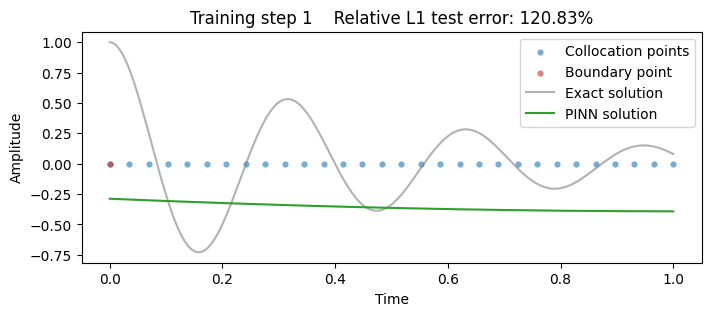

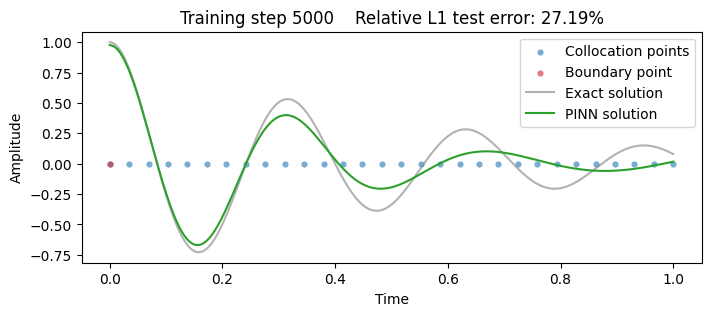

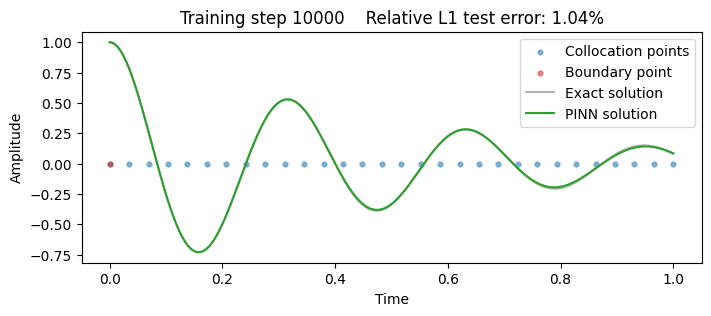

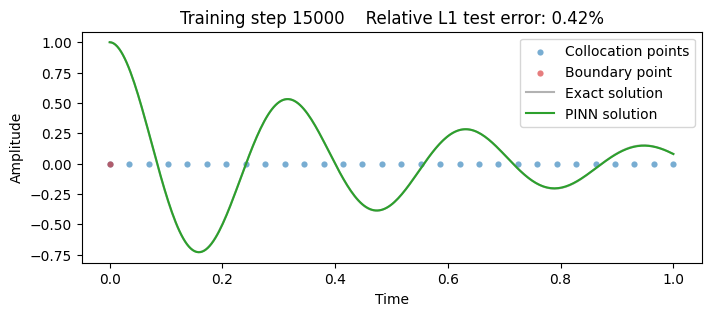

Total training time: 74.38664817810059 seconds


In [19]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,20,2)

# define boundary points, for the boundary loss
# TODO # (1, 1)
t_boundary = torch.tensor([[0.]], requires_grad=True)

# define training points over the entire domain, for the physics loss
# TODO # (30, 1)
t_physics = torch.linspace(0, 1, 30).view(-1, 1).requires_grad_(True)

# train the PINN
d, w0 = 2, 20
mu, k = 2*d, w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)

# --- Optimizer changes: Combination of Adam and LBFGS ---
# Commented out the old Adam optimizer
# optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-3)

# Define Adam and LBFGS optimizers
optimizer_adam = torch.optim.Adam(pinn.parameters(), lr=1e-3)
# LBFGS is a more memory-intensive optimizer, good for fine-tuning after Adam
optimizer_lbfgs = torch.optim.LBFGS(pinn.parameters(), lr=1.0, max_iter=50000, history_size=100)

start = time.time()
N_ADAM_STEPS = 10000 # Use Adam for initial convergence
N_LBFGS_STEPS = 5000 # Use LBFGS for fine-tuning
TOTAL_STEPS = N_ADAM_STEPS + N_LBFGS_STEPS # Total steps remain 15000

def compute_simulation_loss():
    # compute each term of the PINN loss function above
    # using the following hyperparameters
    lambda1, lambda2 = 1e-1, 1e-4

    # compute boundary loss
    u_0 = pinn(t_boundary)
    loss1 = torch.mean((u_0 - 1)**2) # Enforces u(0) = 1

    dudt_0 = torch.autograd.grad(u_0, t_boundary, torch.ones_like(u_0), create_graph=True)[0]
    loss2 = torch.mean((dudt_0 - 0)**2) # Enforces du/dt(0) = 0

    # compute physics loss
    u = pinn(t_physics)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]

    # Residual of: m*u'' + mu*u' + k*u = 0 (assuming m=1)
    loss3 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # backpropagate joint loss
    loss = loss1 + lambda1*loss2 + lambda2*loss3
    return loss

for i in range(TOTAL_STEPS):
    if i < N_ADAM_STEPS:
        # Adam optimization step
        optimizer_adam.zero_grad()
        loss_val = compute_simulation_loss()
        loss_val.backward()
        optimizer_adam.step()
    else:
        # LBFGS optimization step requires a closure
        def closure():
            optimizer_lbfgs.zero_grad()
            loss_val = compute_simulation_loss()
            loss_val.backward()
            return loss_val
        optimizer_lbfgs.step(closure)

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(t_test).detach()
        test_error = torch.mean(torch.abs(u-u_exact)/u_exact.std())
        plt.figure(figsize=(8,3))
        plt.scatter(t_physics.detach()[:,0], torch.zeros_like(t_physics)[:,0], s=20, lw=0, color="tab:blue", alpha=0.6, label="Collocation points")
        plt.scatter(t_boundary.detach()[:,0], 0, s=20, lw=0, color="tab:red", alpha=0.6, label="Boundary point")
        plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.title(f"Training step {i+1}    Relative L1 test error: {test_error:.2%}")
        plt.legend()
        plt.show()

print(f"Total training time: {time.time()-start} seconds")

## Task 2: train a PINN to invert for underlying parameters

#### Task

The second task is to use a PINN to **invert** for underlying parameters.

Specifically, our inputs and outputs are:

- Inputs: noisy observations of the oscillator's displacement, $u_{\mathrm{obs}}$
- Outputs: estimate $\mu$, the coefficient of friction

#### Approach

Similar to above, the PINN is trained to directly approximate the solution to the differential equation, i.e.

$$
\hat{u}(t,\theta) \approx u(t)~,
$$

However here we assume $\mu$ is **not known** and we treat it as an additional **learnable parameter** when training the PINN.

#### Loss function

The PINN is trained with the loss function:

$$
L(\theta, \mu)= \frac{1}{N} \sum^{N}_{i} \left( \left[ m\frac{d^2}{dt^2} + \mu \frac{d}{dt} + k \right] \hat{u}(t_{i},\theta)  \right)^2 + \frac{\lambda}{M} \sum^{M}_{j} \left( \hat{u}(t_{j},\theta) - u_{\mathrm{obs}}(t_{j}) \right)^2
$$

True value of mu: 4


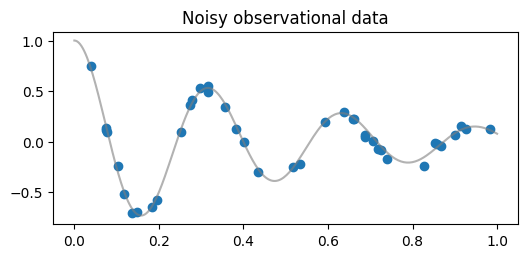

In [20]:
# first, create some noisy observational data
torch.manual_seed(123)
d, w0 = 2, 20
print(f"True value of mu: {2*d}")
t_obs = torch.rand(40).view(-1,1)
u_obs = exact_solution(d, w0, t_obs) + 0.04*torch.randn_like(t_obs)
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)

plt.figure(figsize=(6,2.5))
plt.title("Noisy observational data")
plt.scatter(t_obs[:,0], u_obs[:,0])
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.show()

<>:67: SyntaxWarning: invalid escape sequence '\m'
<>:67: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-3410876776.py:67: SyntaxWarning: invalid escape sequence '\m'
  plt.title("$\mu$")


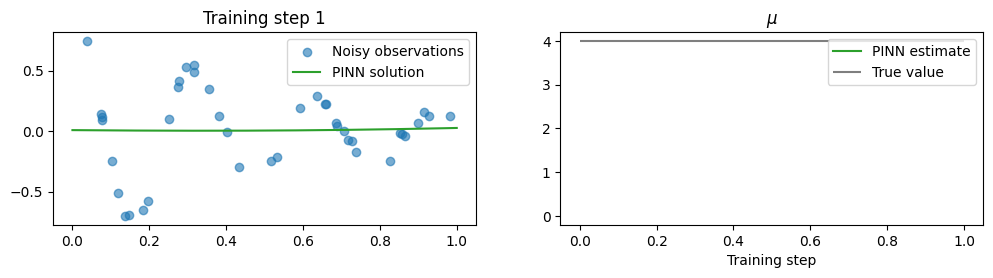

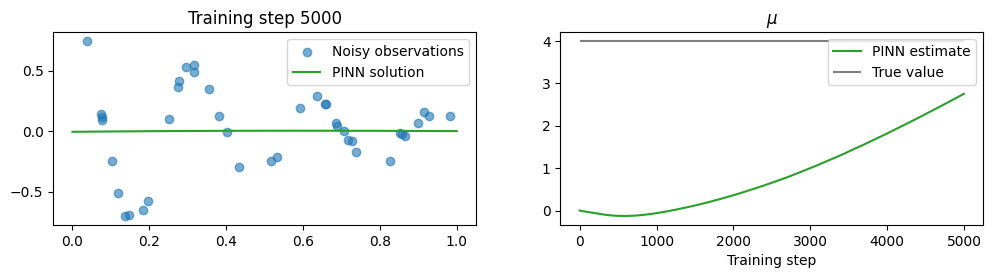

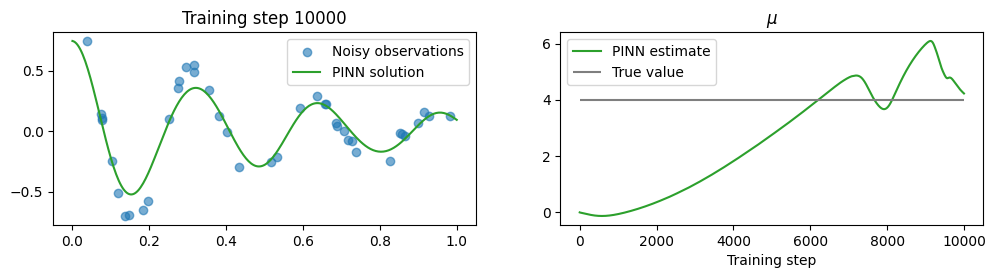

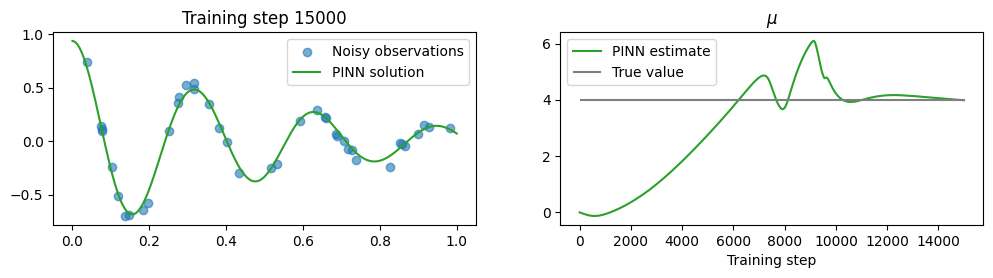

In [24]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,20,2)

# define training points over the entire domain, for the physics loss
t_physics = torch.linspace(0,1,50).view(-1,1).requires_grad_(True)# (50, 1)

# train the PINN
d, w0 = 2, 20
_, k = 2*d, w0**2
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, w0, t_test)

# treat mu as a learnable parameter, add it to optimiser
mu = torch.nn.Parameter(torch.zeros(1, requires_grad=True))
pinn = FCN(1,1,20,2)

# --- Optimizer changes: Reverting to only Adam ---
# Define Adam optimizer, including mu as a learnable parameter
optimizer = torch.optim.Adam(list(pinn.parameters()) + [mu], lr=1e-3)

mus = []
TOTAL_STEPS_INV = 15000 # Revert to original total steps for Adam

def compute_inverse_loss():
    # compute each term of the PINN loss function above
    # using the following hyperparameters
    lambda1 = 1e4

    # compute physics loss
    u = pinn(t_physics)# (50, 1)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]# (50, 1)
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]# (50, 1)
    loss1 = torch.mean((d2udt2 + mu*dudt + k*u)**2)

    # compute data loss
    u_pred = pinn(t_obs)
    loss2 = torch.mean((u_pred - u_obs)**2)

    # backpropagate joint loss
    loss = loss1 + lambda1*loss2
    return loss

for i in range(TOTAL_STEPS_INV):
    # Adam optimization step
    optimizer.zero_grad()
    loss_val = compute_inverse_loss()
    loss_val.backward()
    optimizer.step()

    # record mu value
    mus.append(mu.item())

    # plot the result as training progresses
    if (i+1)%5000 == 0 or i==0:
        u = pinn(t_test).detach()
        plt.figure(figsize=(12,2.5))

        plt.subplot(1,2,1)
        plt.scatter(t_obs[:,0], u_obs[:,0], label="Noisy observations", alpha=0.6, color="tab:blue")
        plt.plot(t_test[:,0], u[:,0], label="PINN solution", color="tab:green")
        plt.title(f"Training step {i+1}")
        plt.legend()

        plt.subplot(1,2,2)
        plt.title(r"$\mu$") # Changed to a raw string to avoid SyntaxWarning
        plt.plot(mus, label="PINN estimate", color="tab:green")
        plt.hlines(2*d, 0, len(mus), label="True value", color="tab:grey")
        plt.xlabel("Training step")
        plt.legend()

        plt.show()